# Task 3.3 회로 트랜스파일 및 최적화

**개요:** 이 노트북에서는 Qiskit이 회로를 어떻게 트랜스파일하고 최적화하는지 다룹니다.

*   **Transpiler 단계**와 각 단계에서 수행되는 작업
*   **Pass manager** , staged pass manager, preset pass manager
*   Pass manager 안에서 사용되는 **Transpiler Pass**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit,QuantumRegister
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.circuit.library import HGate, PhaseGate, RXGate, TdgGate, TGate
from qiskit_ibm_runtime.fake_provider import FakeAuckland,FakeTorino, FakeWashingtonV2
from qiskit.visualization import plot_circuit_layout
from qiskit.transpiler import generate_preset_pass_manager,PassManager, StagedPassManager
from qiskit.transpiler.passes import InverseCancellation
from qiskit.transpiler.passes import UnitarySynthesis, Unroll3qOrMore
from qiskit.transpiler.passes import (
    Collect2qBlocks,
    ConsolidateBlocks,
    UnitarySynthesis,
)

print("라이브러리를 성공적으로 불러왔습니다.")

라이브러리를 성공적으로 불러왔습니다.


In [2]:
# 한글폰트가 깨지는 경우 실행 (깨지지 않았을 때에도 실행해도 무방)

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Malgun Gothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 목표 1 : 트랜스파일러 단계

트랜스파일(transpilation)은 양자 회로를 실제 양자 하드웨어에서 실행 가능하도록 변환하는 과정입니다. 여기에는 다음이 포함됩니다:
- 논리 큐비트를 물리 큐비트에 매핑하기
- 연결성 제약을 만족시키기 위해 SWAP 게이트 추가하기
- 게이트를 하드웨어 고유의 basis gate로 변환하기
- 회로 깊이와 게이트 수 최적화하기
- 유휴 시간을 최소화하도록 연산 스케줄링하기

### **트랜스파일러 단계**

Qiskit의 트랜스파일러는 회로를 다음 단계들로 처리합니다:
1. **Initialization** - 사용자 정의 최적화와 다중 큐비트 게이트 분해
2. **Layout** - 가상 큐비트를 물리 큐비트에 매핑
3. **Routing** - 연결성을 만족시키기 위한 SWAP 게이트 삽입
4. **Translation** - 게이트를 하드웨어 basis로 변환
5. **Optimization** - 회로 깊이와 게이트 수 감소
6. **Scheduling** - 타이밍 정보와 delay 삽입

### 1. Initialization 단계

Initialization 단계에서는 다음 작업을 통해 회로를 트랜스파일 준비 상태로 만듭니다:
- 사용자 정의 최적화 적용
- 다중 큐비트 게이트(2큐비트 초과)를 1큐비트 및 2큐비트 게이트로 분해
- 이후 단계들을 위한 회로 준비

### 2. Layout 단계


Layout 단계에서는 필요한 SWAP 게이트 수를 최소화하는 것을 목표로, 대상 백엔드의 물리 큐비트에 가상 큐비트를 매핑합니다. 대표적인 레이아웃 전략은 다음과 같습니다:

- **TrivialLayout**: 단순한 순차 매핑 (qubit 0→0, 1→1 등)
- **VF2Layout**: 부분그래프 동형성(subgraph isomorphism)을 사용해 최적 매핑을 탐색
- **DenseLayout**: 가장 연결성이 높은 큐비트 부분집합을 선택
- **SabreLayout**: (SWAP-based BidiREctional heuristic search algorithm) 양방향 반복 라우팅을 사용 [https://arxiv.org/pdf/1809.02573](https://arxiv.org/pdf/1809.02573)
- **CSPLayout**: 제약 충족 문제(constraint satisfaction problem) 기반 접근

### 3. Routing 단계

Routing 단계에서는 회로가 하드웨어의 연결 그래프에서 실행 가능하도록 SWAP 게이트를 삽입합니다. 기본적으로 이 단계는 Layout 단계와 함께 계산되는 경우가 많지만, 개념적으로는 서로 구분되는 단계입니다.

대표적인 Routing 방법:
- **SabreSwap**: 가장 널리 쓰이는 휴리스틱 기반 라우팅
- **BasicSwap**: 단순하지만 덜 효율적
- **LookaheadSwap**: 더 정교하지만 계산 비용이 큼

trivial: 평균=65.76, 최소=63, 최대=69
dense: 평균=56.00, 최소=56, 최대=56
sabre: 평균=45.61, 최소=39, 최대=50


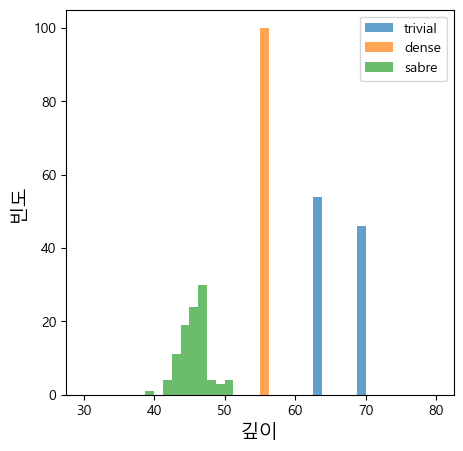

In [3]:
backend = FakeAuckland()
 
ghz = QuantumCircuit(20)
ghz.h(0)
ghz.cx(0, range(1, 15))
 
depths ={"trivial": [], "dense": [], "sabre": []}
for layout_method in ["trivial", "dense", "sabre"]:
    for seed in range(100):
        pass_manager = generate_preset_pass_manager(
            optimization_level=1,
            backend=backend,
            layout_method=layout_method,  # 레이아웃 매핑 방법
            seed_transpiler=seed,  # 재현 가능한 결과를 위한 시드
        )
        depths[layout_method].append(pass_manager.run(ghz).depth())

for layout_method, layout_depths in depths.items():
    print(f"{layout_method}: 평균={sum(layout_depths)/len(layout_depths):.2f}, 최소={min(layout_depths)}, 최대={max(layout_depths)}")

plt.figure(figsize=(5, 5))
for layout_method, layout_depths in depths.items():
    plt.hist(layout_depths, range=(30, 80), alpha=0.7, bins=40, label=layout_method)
plt.xlabel("깊이", fontsize=14)
plt.ylabel("빈도", fontsize=14)
plt.legend()
plt.show()

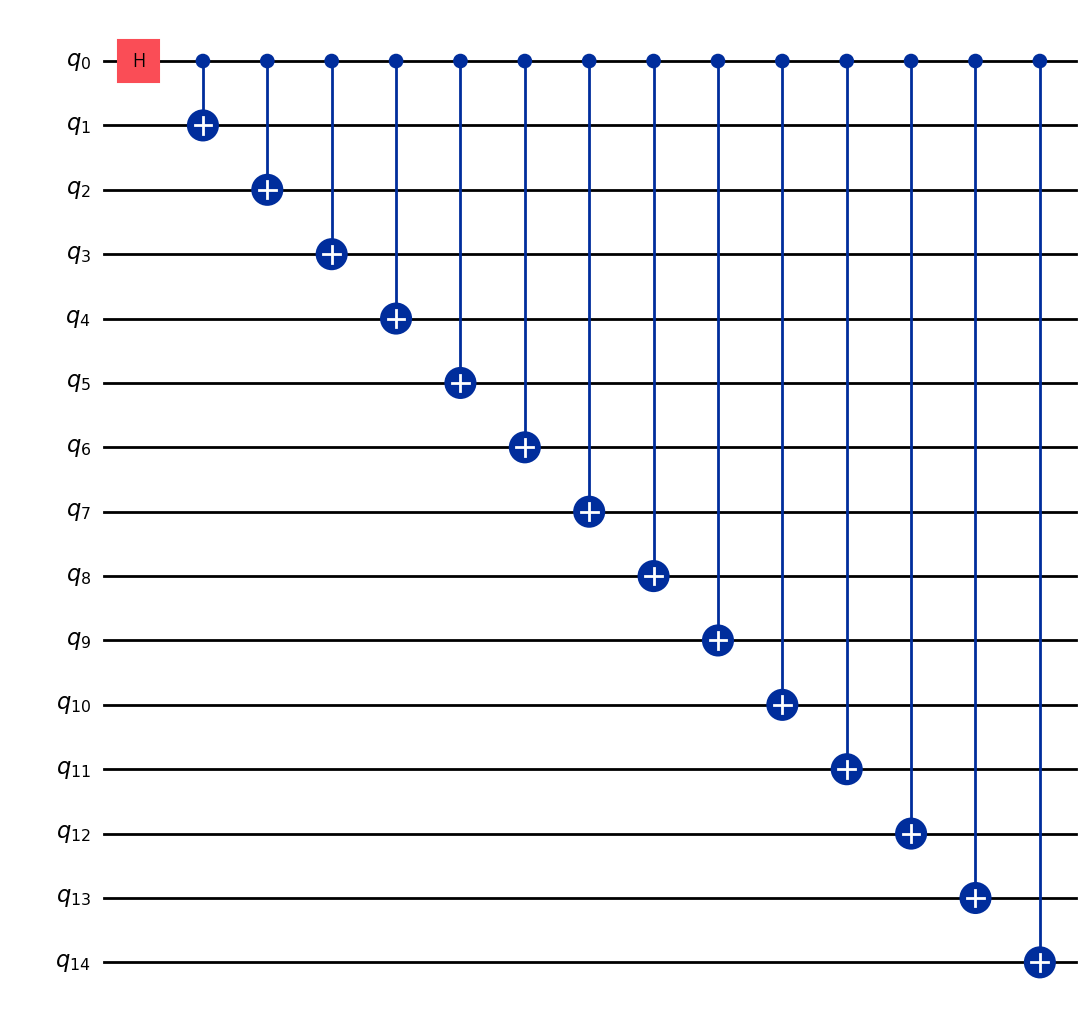

In [4]:
ghz.draw("mpl", idle_wires=False)

원래 GHZ 회로는 20개의 큐비트를 가지며 깊이는 15입니다
트랜스파일된 GHZ 회로는 27개의 큐비트를 가지며 깊이는 44입니다


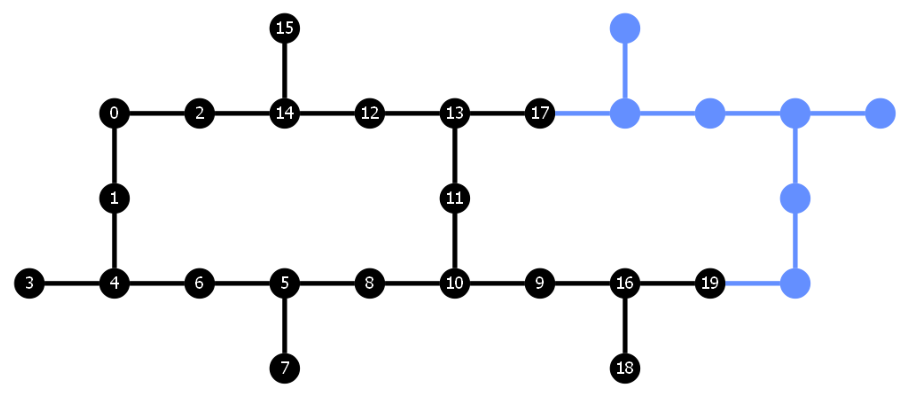

In [5]:
# 원래 회로의 속성 출력
print(f"원래 GHZ 회로는 {ghz.num_qubits}개의 큐비트를 가지며 깊이는 {ghz.depth()}입니다")

# 하드웨어 그래프와 회로 실행에 선택된 하드웨어 큐비트 표시
transpiled_circ = pass_manager.run(ghz)

# 트랜스파일된 회로의 속성 출력
print(f"트랜스파일된 GHZ 회로는 {transpiled_circ.num_qubits}개의 큐비트를 가지며 깊이는 {transpiled_circ.depth()}입니다")

# - plot_circuit_layout()는 가상 큐비트가 물리 큐비트에 어떻게 매핑되는지 보여줍니다
plot_circuit_layout(transpiled_circ, backend)

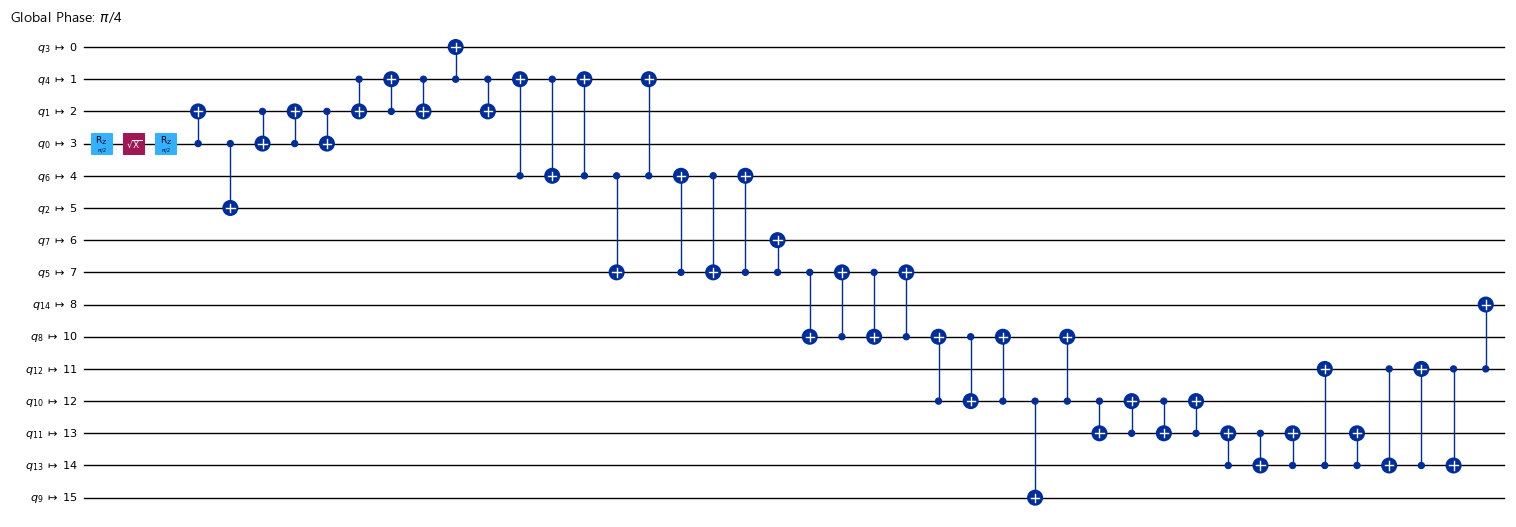

In [6]:
transpiled_circ.draw("mpl", idle_wires=False, fold=-1, scale=0.5)

### **4. Translation 단계**


Translation 단계에서는 회로의 모든 게이트를 하드웨어가 지원하는 native basis gate로 변환합니다. 이 단계 덕분에 회로를 백엔드에서 실행할 수 있지만, 회로 깊이와 게이트 수가 증가할 수 있습니다.

IBM 양자 컴퓨터는 다음을 지원합니다:
- 단일 큐비트 게이트: `['id', 'rz', 'sx', 'x']`
- 2큐비트 게이트: `['cx', 'ecr']`

**Translation 패스**: 
- BasisTranslator: basis 집합에 대한 변환 규칙 집합을 라이브러리에서 탐색
- Decompose: 회로의 게이트를 정의된 decomposition 규칙으로 전개
- Unroll3qOrMore: 회로에 1큐비트/2큐비트 게이트만 남을 때까지 3큐비트 이상 게이트를 전개

native gate: ['cx', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']


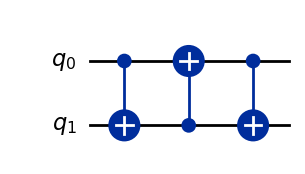

In [7]:
# 백엔드가 지원하는 native gate 출력
print("native gate: " + str(sorted(backend.operation_names)))
# SWAP 게이트는 3개의 CNOT 게이트로 변환됩니다
qc = QuantumCircuit(2)
qc.swap(0, 1)
qc.decompose().draw("mpl")

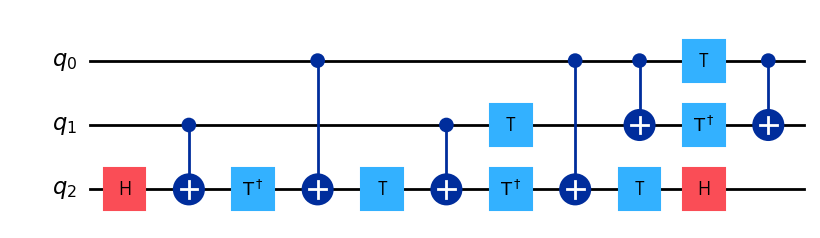

In [8]:
# Toffoli 게이트는 여러 개의 CNOT 및 단일 큐비트 게이트로 변환됩니다 
qc = QuantumCircuit(3)
qc.ccx(0, 1, 2)
qc.decompose().draw("mpl")

### **5. Optimization 단계**

Optimization 단계에서는 다양한 기법을 통해 회로 깊이와 게이트 수를 줄입니다.

**최적화 레벨**:
- Level 0: 최적화 없음
  - 기본 Translation
  - 레이아웃/라우팅: `TrivialLayout` + `SabreSwap`
- Level 1
  - 레이아웃/라우팅: `TrivialLayout`으로 시도, SWAP이 추가적으로 필요한 경우, `SabreSwap` 실행 이후 `VF2LayoutPostLayout`(부분 그래프 동형 이용) 실행
  - `InverseCancellation`: 서로 Inverse 관계에 있는 게이트끼리 상쇄. (예: CX-CX)
  - `Optimize1qGates`: 여러 단일 큐비트 게이트를 하나로 최적화
- Level 2:
  - `CommutativeCancellation`: 교환관계를 이용하여 불필요한 게이트를 상쇄.
- Level 3:
  - `Collect2qBlocks`: 같은 두 큐비트에 연속해서 작용하는 2큐비트 연산 블록을 수집
  - `ConsolidateBlocks`: 수집한 연속 블록을 하나의 `Unitary` 노드로 합쳐 이후 더 좋은 형태로 재합성할 수 있게 함
  - `UnitarySynthesis`: 합쳐진 `Unitary`를 타깃 backend의 basis gate에 맞게 다시 합성하여 더 짧거나 저오차인 회로로 변환
  - `Optimize1qGateDecomposition`: 연속된 1큐비트 게이트들을 하나로 합치고, basis 밖에 있거나 더 낮은 오차로 재합성 가능하면 교체


또한 최종적으로 모든 명령이 백엔드의 basis gate로만 구성되어 있는지 확인합니다.

**Optimization 패스**:
- ~~CXCancellation : 서로 상쇄되는 연속 CX 게이트 제거~~ (Deprecated. Use `InverseCancellation`)
- `CommutativeCancellation`: 서로 가환하면서 역원인 게이트 제거
- `Optimize1qGates`: 연속된 단일 큐비트 게이트 결합

레벨 0: 깊이=73, 전체 게이트 수=101, CX 게이트 수=98
레벨 1: 깊이=47, 전체 게이트 수=47, CX 게이트 수=44
레벨 2: 깊이=43, 전체 게이트 수=53, CX 게이트 수=40
레벨 3: 깊이=44, 전체 게이트 수=48, CX 게이트 수=35


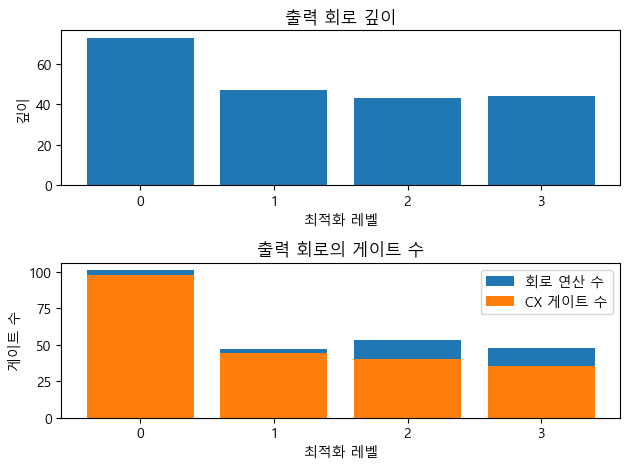

In [9]:
# 서로 다른 최적화 레벨 비교
ghz = QuantumCircuit(15)
ghz.h(0)
ghz.cx(0, range(1, 15))
 
depths = []
gate_counts = []
multiqubit_gate_counts = []
levels = [str(x) for x in range(4)]
# 최적화 레벨 0, 1, 2, 3을 시도
for level in range(4):
    pass_manager = generate_preset_pass_manager(
        optimization_level=level,
        backend=backend,
        seed_transpiler=111,
    )
    circ = pass_manager.run(ghz)
    depths.append(circ.depth())
    gate_counts.append(sum(circ.count_ops().values()))
    multiqubit_gate_counts.append(circ.count_ops()["cx"])
    print(f"레벨 {level}: 깊이={circ.depth()}, 전체 게이트 수={sum(circ.count_ops().values())}, CX 게이트 수={circ.count_ops().get('cx', 0)}")

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.bar(levels, depths, label="깊이")
ax1.set_xlabel("최적화 레벨")
ax1.set_ylabel("깊이")
ax1.set_title("출력 회로 깊이")
ax2.bar(levels, gate_counts, label="회로 연산 수")
ax2.bar(levels, multiqubit_gate_counts, label="CX 게이트 수")
ax2.set_xlabel("최적화 레벨")
ax2.set_ylabel("게이트 수")
ax2.legend()
ax2.set_title("출력 회로의 게이트 수")
fig.tight_layout()
plt.show()

### **6. Scheduling 단계**

Scheduling 단계는 명시적으로 호출해야 하며, 주로 회로에 타이밍 정보를 추가하고 유휴 시간을 반영합니다.
이는 크게 analysis와 constraint mapping의 두 부분으로 나뉩니다.

**Analysis Scheduling 방법**:
- ASAPSchedulingAnalysis: 게이트를 가능한 한 빨리 스케줄링
- ALAPSchedulingAnalysis: 게이트를 가능한 한 늦게 스케줄링

**Constraints 패스**:
- ConstrainedReschedule: 대상 하드웨어의 정렬(alignment) 제약을 반영하도록 노드 시작 시간을 갱신

스케줄된 회로 깊이: 17
회로에 Delay instruction이 포함되어 있는가: True


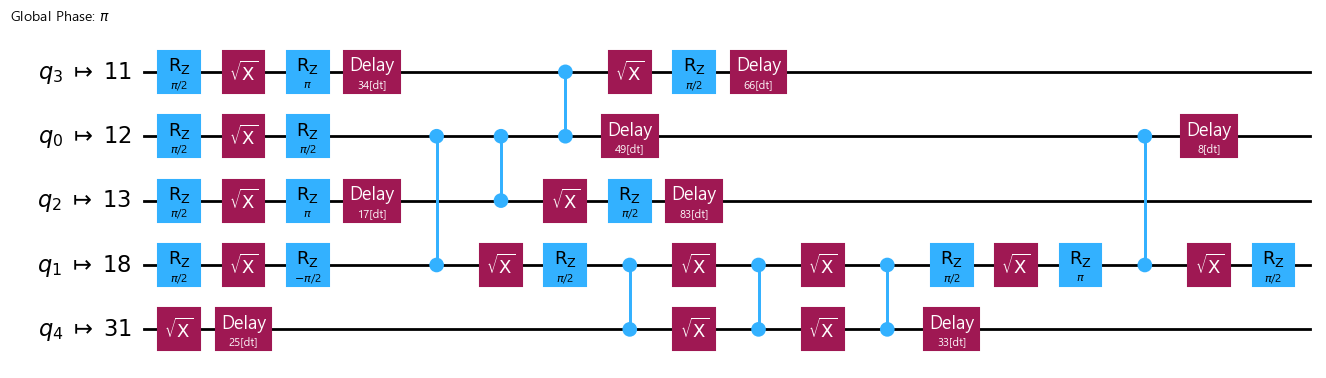

In [10]:
# 스케줄링 시연을 위한 더 작은 GHZ 회로 생성
ghz = QuantumCircuit(5)
ghz.h(0)
ghz.cx(0, range(1, 5))
 
 
# 가짜 백엔드 사용
backend = FakeTorino()
 
# 최적화 레벨 3과 'asap' 또는 'alap' 스케줄링 패스로 실행
pass_manager = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    scheduling_method="asap",
    #scheduling_method="alap",
    seed_transpiler=111,
)
 
 
circ = pass_manager.run(ghz)
print(f"스케줄된 회로 깊이: {circ.depth()}")
print(f"회로에 Delay instruction이 포함되어 있는가: {'delay' in circ.count_ops()}")
circ.draw(output="mpl", idle_wires=False)

스케줄된 회로 깊이: 17
회로에 Delay instruction이 포함되어 있는가: True


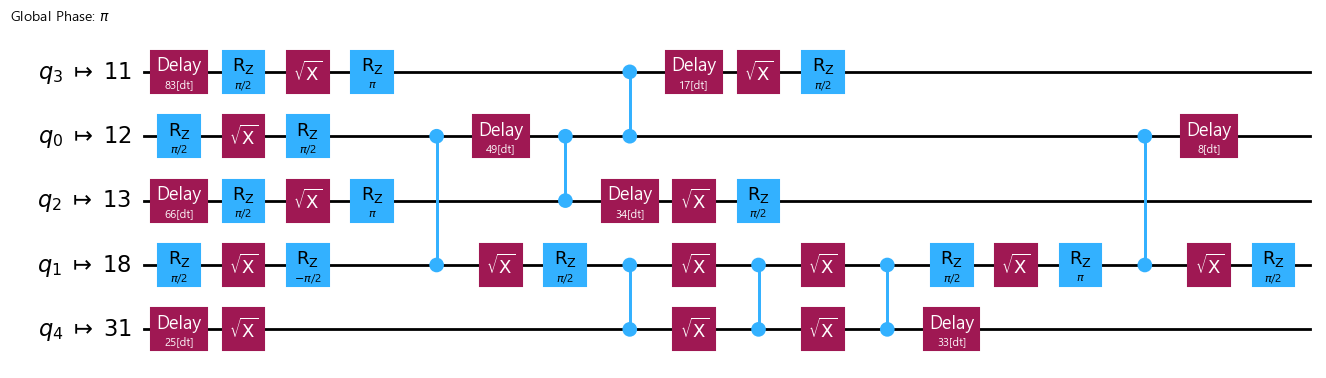

In [11]:
pass_manager = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    scheduling_method="alap",
    seed_transpiler=111,
)
 
 
circ = pass_manager.run(ghz)
print(f"스케줄된 회로 깊이: {circ.depth()}")
print(f"회로에 Delay instruction이 포함되어 있는가: {'delay' in circ.count_ops()}")
circ.draw(output="mpl", idle_wires=False)

## 목표 2: 패스 매니저로 트랜스파일하기

- Pass Manager는 모든 트랜스파일러 패스를 저장하고, `run()` 메서드가 호출되면 이를 실행하는 객체입니다.
- Staged Pass Manager는 pass manager 위의 더 높은 수준 추상화이며, 여러 개의 pass manager로 구성됩니다.
- `generate_preset_pass_manager()` 는 자주 사용되는 패스들이 미리 설정된 pass manager를 생성합니다.

아래 예제에서는 optimization level 3인 preset pass manager를 만듭니다. 그런 다음 pass manager 실행 후 회로 깊이와 게이트 수를 출력합니다.

In [12]:
import os
from dotenv import load_dotenv

load_dotenv('../.env')
api_token = os.getenv("API_TOKEN")

QiskitRuntimeService.save_account(
    token=api_token,
    overwrite=True
)
# 자신의 계정에 있는 백엔드 사용
service = QiskitRuntimeService()
backend = service.backend("ibm_boston")
pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend
)

qiskit_runtime_service.__init__:WARNING:2026-04-07 22:45:12,372: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (internal, premium), the available account instances are: Solutions Demo internal fleet, Educational premium fleet, Educational internal fleet, Solutions Notebooks internal fleet, Solutions Notebooks premium fleet, Solutions Demo premium fleet, Solutions Demo internal fleet, Solutions Notebooks premium fleet, Educational premium fleet, Solutions Notebooks internal fleet, Solutions Demo premium fleet, Educational internal fleet. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-07 22:45:12,373: Using instance: Solutions Notebooks premium fleet, plan: premium


In [13]:
 # 회로 생성
qubits = QuantumRegister(2, name="q")
circuit = QuantumCircuit(qubits)
a, b = qubits
circuit.h(a)
circuit.cx(a, b)
circuit.cx(b, a) # 이는 이전 CX와 상쇄되어야 합니다

# pass manager의 run 메서드를 호출하여 트랜스파일
transpiled = pass_manager.run(circuit) 

print(f"최적화 레벨 3에서 트랜스파일된 회로 깊이: {transpiled.depth()}")
print(f"최적화 레벨 3에서 트랜스파일된 회로의 게이트 수: {transpiled.count_ops()}")

최적화 레벨 3에서 트랜스파일된 회로 깊이: 9
최적화 레벨 3에서 트랜스파일된 회로의 게이트 수: OrderedDict({'rz': 7, 'sx': 5, 'cz': 2})


이 예제에서는 사용자 정의 translation pass manager를 만듭니다. 그 다음 회로에 이를 적용하고, pass manager 실행 전후의 회로를 출력합니다.

In [14]:
# 사용자 정의 translation pass manager 생성
basis_gates = ["rx", "ry", "rxx"]
translation_pass_manager = PassManager(
    [
        Collect2qBlocks(),
        ConsolidateBlocks(basis_gates=basis_gates),
        UnitarySynthesis(basis_gates),
    ]
)

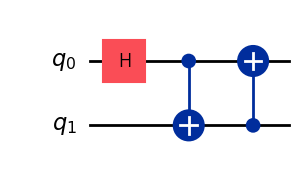

In [15]:
qubits = QuantumRegister(2, name="q")
circuit = QuantumCircuit(qubits)
 
# 사용자 정의 translation 적용
a, b = qubits
circuit.h(a)
circuit.cx(a, b)
circuit.cx(b, a)
 
circuit.draw("mpl")

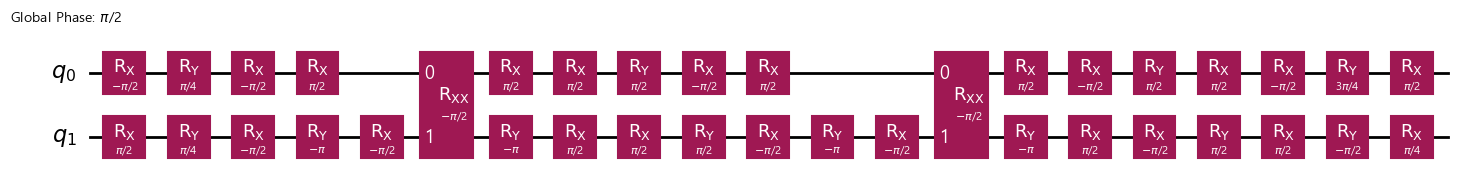

In [16]:
translated = translation_pass_manager.run(circuit)
translated.draw("mpl")

다음 예제는 staged pass manager에 대한 것입니다. 여러 단계를 가질 수 있으며, 각 단계는 자체적인 pass manager로 정의됩니다.

In [17]:
basis_gates = ["rx", "ry", "rxx"]
init_pass_manager = PassManager(
    [UnitarySynthesis(basis_gates, min_qubits=3), Unroll3qOrMore()]
)
# init 및 translation 단계를 가진 staged pass manager 생성
# init_pass_manager와 translation_pass_manager를 사용
staged_pm = StagedPassManager(
    stages=["init", "translation"], init=init_pass_manager, translation=translation_pass_manager
)
print(f"다음 단계로 staged pass manager가 성공적으로 생성되었습니다: {staged_pm.stages}")

다음 단계로 staged pass manager가 성공적으로 생성되었습니다: ('init', 'translation')


또 다른 방법은 preset pass manager를 사용한 뒤 일부 단계를 바꾸는 것입니다. 아래 예제에서는 pre_layout 단계를 추가합니다.

In [18]:
# 사용자 정의 optimization pass 생성 
pass_manager = generate_preset_pass_manager(3, backend)
# 서로 역원으로 나타날 때 상쇄되는 게이트 정의
inverse_gate_list = [
    HGate(),
    (RXGate(np.pi / 4), RXGate(-np.pi / 4)),
    (PhaseGate(np.pi / 4), PhaseGate(-np.pi / 4)),
    (TGate(), TdgGate()),
]

# 논리 최적화 pass manager 생성
logical_opt = PassManager(
    [
        InverseCancellation(inverse_gate_list),
    ]
)
 
# 사용자 정의 최적화를 pre-layout 단계에 추가
pass_manager.pre_layout = logical_opt
print("사용자 정의 inverse cancellation pass가 pre-layout 단계에 추가되었습니다")

사용자 정의 inverse cancellation pass가 pre-layout 단계에 추가되었습니다


## 목표 3 트랜스파일러 패스

### Layout



- **TrivialLayout**: 회로의 n개 큐비트를 장치 큐비트 0, .., n-1에 할당하여 Layout 선택
- **DenseLayout**: 가장 연결성이 높은 큐비트 부분집합을 찾아 Layout 선택
- **SabreLayout**: 입력 회로를 양방향 반복 라우팅하여 Layout 선택
- **CSPLayout**: 가능하면 백트래킹을 사용해 CSP로서 Layout 선택
- **VF2Layout**: 회로를 coupling graph 위에 배치하기 위한 Layout 선택 패스로, 부분그래프 동형성 문제를 VF2++로 풂.

### Routing


- **BasicSwap**: 최소한의 노력으로 DAGCircuit을 coupling_map에 맞게 매핑하고 swap 게이트를 추가
- **Commuting2qGateRouter**: 하나 이상의 서로 가환하는 게이트를 coupling map에 맞게 swap routing
- **LayoutTransformation**: 주어진 (부분) 순열에 대해 회로에 Swap 회로를 추가
- **LookaheadSwap**: SWAP 삽입을 통해 입력 회로를 백엔드 토폴로지에 매핑
- **SabreSwap**: SWAP 삽입을 통해 입력 회로를 백엔드 토폴로지에 매핑
- **StarPreRouting**: star 형태를 line 형태로 바꾸기 위한 pre-routing 수행


### Basis 변경



- **BasisTranslator**: 주어진 EquivalenceLibrary에서 변환 집합을 찾아 게이트를 목표 basis로 변환
- **Decompose**: 회로의 게이트를 decomposition 규칙에 따라 전개
- **TranslateParameterizedGates**: 매개변수화된 게이트를 지원되는 basis 집합으로 변환
- **Unroll3qOrMore**: 회로에 2큐비트 또는 1큐비트 게이트만 남을 때까지 3큐비트 이상 게이트를 재귀적으로 전개
- **UnrollCustomDefinitions**: 사용자 정의 instruction을 unroll

### 최적화



- **Collect1qRuns**: 1큐비트 부분회로를 수집
- **Collect2qBlocks**: 2큐비트 부분회로를 수집
- **CommutativeCancellation**: 가환 관계를 이용해 중복되는(자기수반) 게이트를 제거
- **ConsolidateBlocks**: 연속된 각 게이트 블록을 하나의 Unitary 노드로 대체
- **InverseCancellation**: 서로 역원 관계인 특정 게이트가 연속으로 나타날 때 제거
- **Optimize1qGates**: 연속된 단일 큐비트 u1, u2, u3 게이트를 하나의 게이트로 결합하여 최적화
- **Optimize1qGatesDecomposition**: 연속된 단일 큐비트 게이트를 하나의 게이트로 결합하여 최적화
- **Optimize1qGatesSimpleCommutation**: 2Q 게이트에 의해 끊긴 1Q 게이트 문자열을 가환시켜 이동한 뒤 재합성하여 최적화

### Scheduling

- **ALAPScheduleAnalysis**: 명령의 종료 시점을 가능한 한 늦게 배치하는 ALAP 스케줄링 패스
- **ASAPScheduleAnalysis**: 명령의 시작 시점을 가능한 한 빠르게 배치하는 ASAP 스케줄링 패스
- **ConstrainedReschedule**: 하드웨어 정렬 제약에 맞도록 노드 시작 시간을 갱신하는 재스케줄링 패스
- **ContextAwareDynamicalDecoupling**: 게이트 및 큐비트 문맥을 고려한 X-시퀀스 dynamical decoupling 구현
- **InstructionDurationCheck**: 재스케줄링을 위한 duration 검증 패스
- **PadDelay**: 유휴 시간을 Delay instruction으로 채움
- **PadDynamicalDecoupling**: dynamical decoupling 삽입 패스
- **SetIOLatency**: 입력 회로에 IOLatency 정보 설정
- **TimeUnitConversion**: 이후 시간 의존 패스에서 사용할 시간 단위를 선택하고 회로의 시간 단위를 일관되게 변환


위의 다섯 가지 트랜스파일러 패스 외에도, Qiskit은 회로 분석, 합성, post-layout 등 다양한 추가 패스를 제공합니다. 사용 가능한 전체 트랜스파일러 패스 목록은 다음에서 볼 수 있습니다: https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler_passes

---
# 요약
---

이 노트북에서는 다음을 다뤘습니다:

## 회로 트랜스파일:

1. **트랜스파일러 단계**는 양자 회로를 특정 하드웨어에서 실행 가능하게 만들기 위해 거치는 단계들입니다.
    * Initialization: 사용자 정의 최적화를 적용하고 다중 큐비트 게이트를 1큐비트 및 2큐비트 게이트로 분해하여 회로를 준비합니다.
    * Layout: 회로의 논리(가상) 큐비트를 백엔드의 물리 큐비트에 매핑합니다.
    * Routing: 큐비트 매핑 이후 하드웨어 연결성 제약을 만족시키기 위해 SWAP 게이트를 삽입합니다.
    * Translation: 회로의 모든 게이트를 하드웨어의 native basis gate로 변환합니다.
    * Optimization: 회로 깊이와 게이트 수를 줄입니다.
    * Scheduling: 타이밍 정보를 추가하고, 유휴 시간을 반영하며, delay를 삽입합니다.
2. **Pass manager**는 트랜스파일러 패스들의 순서를 관리하고 실행하는 데 사용되며, `PassManager`, `StagedPassManager`, `generate_preset_pass_manager()` 를 사용할 수 있습니다.
3. **트랜스파일러 패스**는 특정 양자 장치에서 회로를 실행할 수 있도록 회로를 변환하는 pass manager 내부의 단계들입니다. 크게 5가지 주요 패스로 나뉘지만, 사용자 정의 pass manager에 추가할 수 있는 다른 패스들도 존재합니다.


---


## 연습 문제

**1) 다음 중 Qiskit 파이프라인의 네 가지 주요 트랜스파일러 단계를 올바르게 나열한 것은 무엇인가요?**

A) Initialization → Optimization → Scheduling → Circuit Analysis

B) Pre-Layout → Layout → Post-Layout → Optimization

C) Layout → Routing → Transformation → Optimization → Scheduling

D) Parsing →  Compilation → Simulation → Execution

E) Layout → Routing → Optimization → Scheduling


***정답:***
<Details>
<br/>
올바른 순서는 
E) Layout → Routing → Optimization → Scheduling 
</Details>

---


**2) 아래 코드에서 `Unroll3qOrMore` 패스는 무엇을 하나요?**



```
from qiskit.transpiler.passes import Unroll3qOrMore
pm = PassManager([Unroll3qOrMore()])
tc = pm.run(qc)
```

A) 측정을 고전 레지스터로 바꾼다

B) 모든 게이트를 3큐비트 이상 게이트로 변환한다

C) 다중 큐비트 게이트를 지원되는 1큐비트 및 2큐비트 basis gate로 분해한다

D) 회전 게이트를 병합하여 회로를 최적화한다


***정답:***
<Details>
<br/>
 
C) 다중 큐비트 게이트를 지원되는 1큐비트 및 2큐비트 basis gate로 분해한다
 
</Details>